# Radiation and Antennas — Accelerating Charges, the Dipole, and the sin²θ Donut

A charge gliding at constant velocity carries its fields along and radiates nothing. **Accelerate**
it and energy leaks away as electromagnetic radiation — that is the *toll* of acceleration, the
**Larmor formula** $P=\dfrac{\mu_0 q^2 a^2}{6\pi c}$. An oscillating charge is an **antenna**: the
elemental oscillating dipole radiates the famous **sin²θ donut**, broadside-bright and axis-dark.

The same dipole, at optical frequency, *is an atom emitting a photon* — so "antenna" and "what
atoms am I interacting with" are the radio and optical ends of one physics. Engine:
`griffiths.radiation` (Griffiths Ch. 11).

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from IPython.display import display, Math

import griffiths as gr
from griffiths import radiation as rad

sp.init_printing(use_latex="mathjax")
q, a, p0, omega = sp.symbols("q a p_0 omega", positive=True)
theta = sp.Symbol("theta", positive=True)
print("griffiths.radiation loaded")

griffiths.radiation loaded


## §1 Accelerating charges radiate — the Larmor formula

Total radiated power scales with the *square of the acceleration*. The angular distribution
$\dfrac{dP}{d\Omega}\propto\sin^2\theta$ (measured from the acceleration axis) integrates back to the
total — radiated mostly sideways, nothing straight ahead.

In [2]:
P = rad.larmor_power(q, a)
display(Math(r"P = " + sp.latex(P) + r" = \frac{\mu_0 q^2 a^2}{6\pi c}"))
display(Math(r"\frac{dP}{d\Omega} = " + sp.latex(rad.larmor_angular(q, a))))
total = sp.integrate(rad.larmor_angular(q, a)*sp.sin(theta), (theta, 0, sp.pi))*2*sp.pi
print("angular distribution integrates to Larmor P:", sp.simplify(total - P) == 0)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

angular distribution integrates to Larmor P: True


## §2 The oscillating dipole — the elemental antenna

A dipole $p(t)=p_0\cos\omega t$ radiates a transverse far field $E_\theta\propto\sin\theta/r$ (note
$1/r$, not $1/r^2$ — that is what carries energy to infinity), and average power

$$\langle P\rangle=\frac{\mu_0 p_0^2\omega^4}{12\pi c}.$$

The $\omega^4$ is why **the sky is blue**: higher frequencies radiate far more strongly, so scattered
sunlight is dominated by blue.

In [3]:
r, t = sp.symbols("r t", positive=True)
display(Math(r"E_\theta = " + sp.latex(rad.dipole_E_theta(p0, omega, r, t))))
display(Math(r"\langle P\rangle = " + sp.latex(rad.dipole_average_power(p0, omega))
             + r"\quad(\propto\omega^4:\ \text{Rayleigh, blue sky})"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## §3 The radiation pattern: the sin²θ donut

Power per solid angle $\propto\sin^2\theta$ — maximum broadside ($\theta=90°$), a perfect **null**
along the dipole axis. In 3-D it is a torus (donut) wrapped around the antenna.

C:\Users\mrjel\AppData\Local\Temp\ipykernel_44036\198472299.py:10: RuntimeWarning: divide by zero encountered in divide
  hw = (np.cos(np.pi/2*np.cos(th))/np.sin(th))**2
C:\Users\mrjel\AppData\Local\Temp\ipykernel_44036\198472299.py:12: RuntimeWarning: invalid value encountered in divide
  ax2.plot(th, hw/hw.max(), "C3", lw=2); ax2.plot(-th, hw/hw.max(), "C3", lw=2)


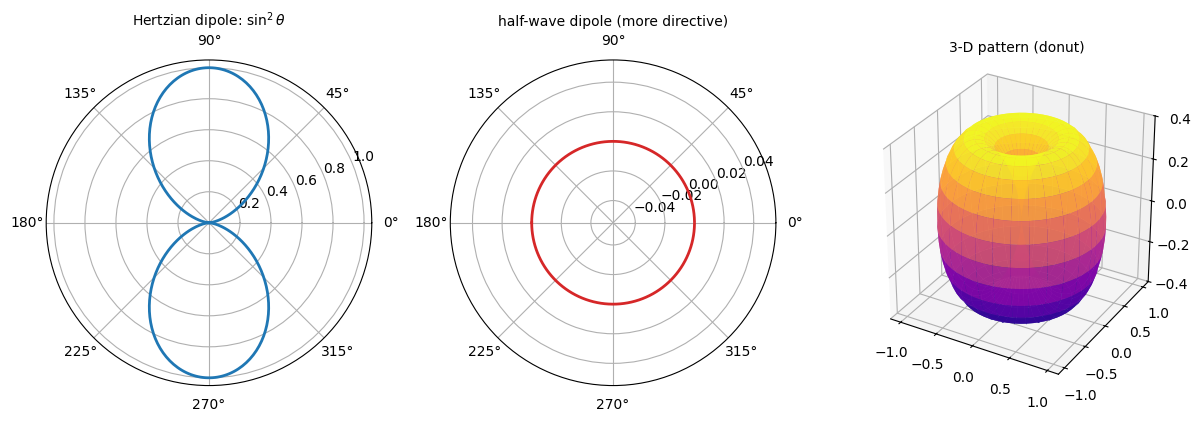

In [4]:
th = np.linspace(0, np.pi, 200)
fig = plt.figure(figsize=(12, 4.2))

# polar pattern
ax1 = fig.add_subplot(1, 3, 1, projection="polar")
ax1.plot(th, np.sin(th)**2, "C0", lw=2); ax1.plot(-th, np.sin(th)**2, "C0", lw=2)
ax1.set_title("Hertzian dipole: $\\sin^2\\theta$", fontsize=10)

# half-wave dipole (sharper)
hw = (np.cos(np.pi/2*np.cos(th))/np.sin(th))**2
ax2 = fig.add_subplot(1, 3, 2, projection="polar")
ax2.plot(th, hw/hw.max(), "C3", lw=2); ax2.plot(-th, hw/hw.max(), "C3", lw=2)
ax2.set_title("half-wave dipole (more directive)", fontsize=10)

# 3D donut
ax3 = fig.add_subplot(1, 3, 3, projection="3d")
TH, PH = np.meshgrid(np.linspace(0, np.pi, 60), np.linspace(0, 2*np.pi, 60))
R = np.sin(TH)**2
X = R*np.sin(TH)*np.cos(PH); Y = R*np.sin(TH)*np.sin(PH); Z = R*np.cos(TH)
ax3.plot_surface(X, Y, Z, cmap="plasma", alpha=0.9, linewidth=0)
ax3.set_title("3-D pattern (donut)", fontsize=10); ax3.set_box_aspect((1, 1, 1))
plt.tight_layout(); plt.show()

## §4 The antenna as a transceiver — directivity and reciprocity

**Directivity** $D=P_{\max}/\langle P\rangle_{\rm sphere}$ measures focusing over an isotropic
radiator. Hertzian dipole: $D=\tfrac32$. Half-wave dipole: $D\approx1.64$ (2.15 dBi) — the workhorse.
By **reciprocity** an antenna's transmit and receive patterns are identical, so the same donut tells
you both how it broadcasts and how well it hears from each direction.

In [5]:
print("Hertzian dipole directivity D =", rad.directivity("hertzian"), "(=3/2)")
Dhw = float(rad.directivity("half_wave"))
print(f"half-wave dipole directivity D = {Dhw:.3f}  ({10*np.log10(Dhw):.2f} dBi)")
print("pattern solid-angle integral (hertzian):", rad.total_pattern_solid_angle("hertzian"), "= 8 pi/3")
print("\nreciprocity: transmit pattern == receive pattern (same donut for TX and RX).")

Hertzian dipole directivity D = 3/2 (=3/2)


half-wave dipole directivity D = 1.641  (2.15 dBi)
pattern solid-angle integral (hertzian): 8*pi/3 = 8 pi/3

reciprocity: transmit pattern == receive pattern (same donut for TX and RX).


## §5 Odd vs even — why antennas are dipoles

A $2^\ell$-pole radiation field has parity $(-1)^\ell$: the **dipole is odd**, the quadrupole even,
and so on. The leading nonzero multipole dominates the far field, and for a driven antenna that is
almost always the (odd) electric dipole — quadrupole and higher radiate far more weakly. Odd vs even
is not cosmetic here; it sets which term you actually detect.

In [6]:
for order, name in [(1, "dipole"), (2, "quadrupole"), (3, "octupole")]:
    par = rad.multipole_parity(order)
    print(f"  {name:11} (2^{order}-pole): parity {par:+d}  ({'odd' if par<0 else 'even'})")
print("\nleading (odd dipole) term dominates -> antennas are dipoles.")

  dipole      (2^1-pole): parity -1  (odd)
  quadrupole  (2^2-pole): parity +1  (even)
  octupole    (2^3-pole): parity -1  (odd)

leading (odd dipole) term dominates -> antennas are dipoles.


## §6 Where this lands

- **Antenna = radiating atom.** The oscillating dipole here is, at optical frequency, an atom or
  molecule emitting a photon — "optical antennas" and nanophotonic emitters are this same $\sin^2\theta$
  physics. "What atoms am I interacting with" is answered by the *spectrum* they radiate, the $\omega^4$-
  weighted dipole emission this notebook computes.
- **Radiation is phase.** The far field $E_\theta\propto\cos(\omega(t-r/c))$ carries the source's phase
  outward; reading that phase back from intensity is precisely the carrier-less phase-recovery problem
  of `gs_core.py`. A transceiver that recovers phase from a square-law detector is the TD-GS receiver.
- **Noether / conservation.** The radiated power is energy leaving the source; the $\sin^2\theta$
  pattern and total $P$ are bookkeeping for the conservation law. And radiation is frame-dependent —
  what looks like a static field in one frame radiates in another, the boost machinery of PS#1.

Engine added this session: `griffiths/radiation.py` (Larmor, dipole fields & power, radiation
patterns, directivity, multipole parity), benchmarked in `scripts/smoke_radiation.py`. The `griffiths`
package now reaches Griffiths Ch. 11 (radiation).